
# France Sovereign Debt Dynamics — `01_debt_dynamics.ipynb`

## Objective

Build a transparent, auditable deterministic model of French sovereign debt dynamics before moving to stochastic or econometric models.

The notebook answers four questions:

1. What primary balance is required to stabilize French debt/GDP?
2. How quickly do higher market yields feed into the effective interest cost of the debt stock?
3. How sensitive is the debt trajectory to nominal GDP growth and new borrowing costs?
4. Under different long-end OAT scenarios, how large could the required fiscal adjustment become?

This notebook is **not a forecast** and does **not estimate a literal yield ceiling**. It is an accounting/stress-testing engine that later notebooks can use.

---

## Core accounting identity

\[
d_t =
\frac{1+i_t}{1+g_t}d_{t-1}
-
pb_t
\]

where:

- \(d_t\): debt/GDP
- \(i_t\): effective nominal interest rate on the outstanding debt stock
- \(g_t\): nominal GDP growth
- \(pb_t\): primary balance/GDP; positive means surplus

The debt-stabilizing primary balance is:

\[
pb_t^* =
\left(
\frac{1+i_t}{1+g_t}-1
\right)d_{t-1}
\]

A key distinction used throughout:

\[
\text{30Y OAT yield}
\neq
\text{average new funding cost}
\neq
\text{effective rate on existing debt}
\]



## Baseline source notes

Starting values are based on the latest authoritative data available when this notebook was created (2 October 2026):

**IMF 2026 Article IV for France**
- 2026 general-government gross debt: 118.5% of GDP
- 2026 primary balance: -2.7% of GDP
- 2026 real GDP growth: 0.6%
- 2026 GDP deflator growth: 1.5%
- 2026 overall balance: -5.2% of GDP

**Agence France Trésor (31 August 2026)**
- Negotiable government debt outstanding: €2.904tn
- Average maturity of negotiable debt: 8 years 142 days
- Medium/long-term debt average maturity: 9 years 17 days
- Weighted-average 2026 OAT issuance yield through August: 3.50%

The model deliberately exposes all assumptions in editable cells.


In [24]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Baseline inputs

In [25]:

# ============================================================
# BASELINE INPUTS — FRANCE, 2026
# ============================================================

# Fiscal position
initial_debt_gdp = 1.185       # 118.5% of GDP
primary_balance = -0.027       # -2.7% of GDP; deficit is negative

# Nominal GDP growth components
real_gdp_growth = 0.006        # +0.6%
gdp_deflator_growth = 0.015    # +1.5%

nominal_growth = (
    (1 + real_gdp_growth)
    * (1 + gdp_deflator_growth)
    - 1
)

# Approximate 2026 interest expenditure:
# IMF overall deficit -5.2%; primary deficit -2.7%.
# Difference is approximately 2.5% of GDP.
interest_expense_gdp = 0.025

# Approximate effective interest rate embedded in the existing debt stock
initial_effective_rate = interest_expense_gdp / initial_debt_gdp

# AFT average maturity
average_maturity_years = 8 + 142 / 365

# Version 0.1 approximation:
# assume this fraction of the debt stock reprices each year.
repricing_speed = 1 / average_maturity_years

# AFT weighted-average OAT issuance yield through August 2026.
# This is a historical 2026 issuance average, NOT a current full-curve funding cost.
baseline_new_borrowing_rate = 0.035

projection_years = 20

print(f"Nominal GDP growth:             {nominal_growth:.2%}")
print(f"Initial effective rate:        {initial_effective_rate:.2%}")
print(f"Average debt maturity:         {average_maturity_years:.2f} years")
print(f"Approx. annual repricing rate: {repricing_speed:.2%}")


Nominal GDP growth:             2.11%
Initial effective rate:        2.11%
Average debt maturity:         8.39 years
Approx. annual repricing rate: 11.92%



### Interpretation

The initial effective debt cost and nominal GDP growth are both close to 2.1%.

That means the current debt stock is not yet generating a large adverse \(i-g\) snowball. The immediate fiscal problem is the **primary deficit**, while the medium-term risk comes from refinancing old low-coupon debt at materially higher rates.


## 2. Core model functions

In [26]:

def debt_stabilizing_primary_balance(
    debt_ratio,
    effective_rate,
    nominal_growth
):
    '''
    Primary balance required to keep debt/GDP unchanged.

    Positive result = required primary surplus.
    Negative result = a primary deficit could be consistent with stable debt.
    '''
    return (
        ((1 + effective_rate) / (1 + nominal_growth) - 1)
        * debt_ratio
    )


def update_effective_interest_rate(
    previous_effective_rate,
    new_borrowing_rate,
    repricing_speed
):
    '''
    Version 0.1 repricing model.

    A fraction of the debt stock is assumed to refinance each year
    at the prevailing average rate on new borrowing.
    '''
    return (
        (1 - repricing_speed) * previous_effective_rate
        + repricing_speed * new_borrowing_rate
    )


def next_debt_ratio(
    previous_debt_ratio,
    effective_rate,
    nominal_growth,
    primary_balance
):
    '''
    Exact one-period debt/GDP accounting equation.
    '''
    return (
        ((1 + effective_rate) / (1 + nominal_growth))
        * previous_debt_ratio
        - primary_balance
    )


## 3. Validation tests

In [27]:

# Test 1:
# If i == g and the primary balance is zero,
# debt/GDP must stay constant.

test_debt = next_debt_ratio(
    previous_debt_ratio=1.20,
    effective_rate=0.03,
    nominal_growth=0.03,
    primary_balance=0.00
)

assert np.isclose(test_debt, 1.20)
print("Test 1 passed.")


Test 1 passed.


In [28]:

# Test 2:
# If the primary balance equals the analytically calculated
# debt-stabilizing balance, debt/GDP must stay constant.

test_debt_ratio = 1.20
test_rate = 0.05
test_growth = 0.03

test_pb = debt_stabilizing_primary_balance(
    debt_ratio=test_debt_ratio,
    effective_rate=test_rate,
    nominal_growth=test_growth
)

test_next_debt = next_debt_ratio(
    previous_debt_ratio=test_debt_ratio,
    effective_rate=test_rate,
    nominal_growth=test_growth,
    primary_balance=test_pb
)

assert np.isclose(test_next_debt, test_debt_ratio)
print("Test 2 passed.")


Test 2 passed.


## 4. Multi-year deterministic projection engine

In [29]:

def project_debt_path(
    initial_debt_ratio,
    initial_effective_rate,
    new_borrowing_rate,
    nominal_growth,
    primary_balance,
    repricing_speed,
    years=20
):
    debt = initial_debt_ratio
    effective_rate = initial_effective_rate

    results = []

    for year in range(1, years + 1):
        debt_start = debt

        effective_rate = update_effective_interest_rate(
            previous_effective_rate=effective_rate,
            new_borrowing_rate=new_borrowing_rate,
            repricing_speed=repricing_speed
        )

        required_pb = debt_stabilizing_primary_balance(
            debt_ratio=debt_start,
            effective_rate=effective_rate,
            nominal_growth=nominal_growth
        )

        fiscal_gap = required_pb - primary_balance

        # Interest spending as a share of current-year GDP.
        interest_expense_ratio = (
            effective_rate
            * debt_start
            / (1 + nominal_growth)
        )

        debt = next_debt_ratio(
            previous_debt_ratio=debt_start,
            effective_rate=effective_rate,
            nominal_growth=nominal_growth,
            primary_balance=primary_balance
        )

        results.append({
            "year": year,
            "debt_gdp": debt,
            "effective_rate": effective_rate,
            "new_borrowing_rate": new_borrowing_rate,
            "nominal_growth": nominal_growth,
            "primary_balance": primary_balance,
            "required_primary_balance": required_pb,
            "fiscal_gap": fiscal_gap,
            "interest_expense_gdp": interest_expense_ratio
        })

    return pd.DataFrame(results)


## 5. Baseline no-policy-change stress test

In [30]:

baseline = project_debt_path(
    initial_debt_ratio=initial_debt_gdp,
    initial_effective_rate=initial_effective_rate,
    new_borrowing_rate=baseline_new_borrowing_rate,
    nominal_growth=nominal_growth,
    primary_balance=primary_balance,
    repricing_speed=repricing_speed,
    years=projection_years
)

baseline.head()


,year,debt_gdp,effective_rate,new_borrowing_rate,nominal_growth,primary_balance,required_primary_balance,fiscal_gap,interest_expense_gdp
0,1,1.2139,0.0228,0.0350,0.0211,-0.0270,0.0019,0.0289,0.0264
1,2,1.2446,0.0242,0.0350,0.0211,-0.0270,0.0037,0.0307,0.0288
2,3,1.2770,0.0255,0.0350,0.0211,-0.0270,0.0054,0.0324,0.0311
3,4,1.3110,0.0266,0.0350,0.0211,-0.0270,0.0069,0.0339,0.0333
4,5,1.3463,0.0276,0.0350,0.0211,-0.0270,0.0084,0.0354,0.0355



**Important:** this is intentionally *not* the IMF forecast.

It freezes the primary balance at -2.7% of GDP for 20 years so that we can see the mechanical consequence of **no fiscal adjustment**. It is a stress test, not a prediction.


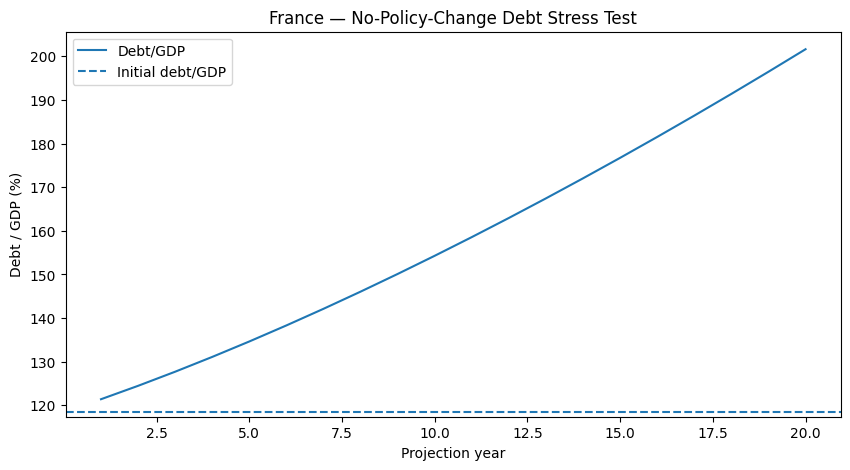

In [31]:

plt.figure(figsize=(10, 5))
plt.plot(
    baseline["year"],
    baseline["debt_gdp"] * 100,
    label="Debt/GDP"
)
plt.axhline(
    initial_debt_gdp * 100,
    linestyle="--",
    label="Initial debt/GDP"
)
plt.xlabel("Projection year")
plt.ylabel("Debt / GDP (%)")
plt.title("France — No-Policy-Change Debt Stress Test")
plt.legend()
plt.show()


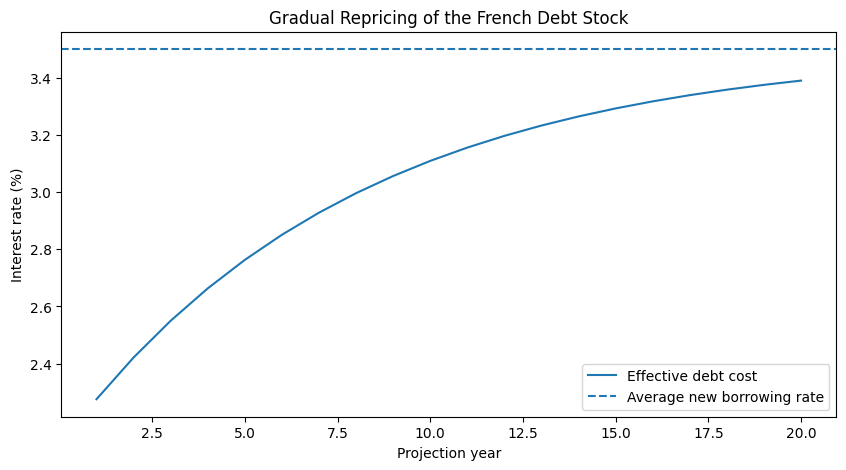

In [32]:

plt.figure(figsize=(10, 5))
plt.plot(
    baseline["year"],
    baseline["effective_rate"] * 100,
    label="Effective debt cost"
)
plt.axhline(
    baseline_new_borrowing_rate * 100,
    linestyle="--",
    label="Average new borrowing rate"
)
plt.xlabel("Projection year")
plt.ylabel("Interest rate (%)")
plt.title("Gradual Repricing of the French Debt Stock")
plt.legend()
plt.show()


## 6. New-borrowing-cost scenarios

In [33]:

new_rate_scenarios = [
    0.035,
    0.040,
    0.045,
    0.050,
    0.055,
    0.060
]

scenario_results = {}

for rate in new_rate_scenarios:
    scenario_results[rate] = project_debt_path(
        initial_debt_ratio=initial_debt_gdp,
        initial_effective_rate=initial_effective_rate,
        new_borrowing_rate=rate,
        nominal_growth=nominal_growth,
        primary_balance=primary_balance,
        repricing_speed=repricing_speed,
        years=projection_years
    )


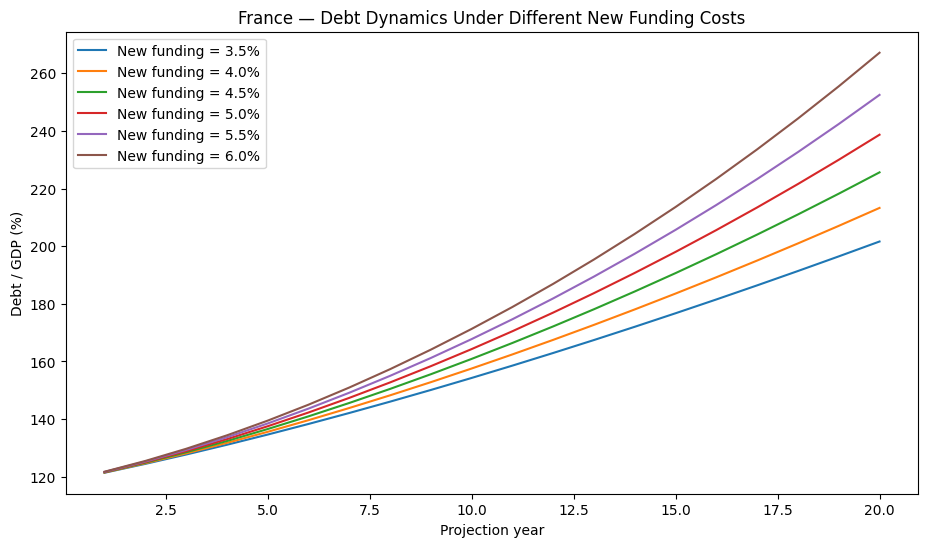

In [34]:

plt.figure(figsize=(11, 6))

for rate, df in scenario_results.items():
    plt.plot(
        df["year"],
        df["debt_gdp"] * 100,
        label=f"New funding = {rate:.1%}"
    )

plt.xlabel("Projection year")
plt.ylabel("Debt / GDP (%)")
plt.title("France — Debt Dynamics Under Different New Funding Costs")
plt.legend()
plt.show()


In [35]:

scenario_summary = []

for rate, df in scenario_results.items():
    year_5 = df.loc[df["year"] == 5].iloc[0]
    year_10 = df.loc[df["year"] == 10].iloc[0]
    year_20 = df.loc[df["year"] == 20].iloc[0]

    scenario_summary.append({
        "new_funding_cost": rate,
        "debt_gdp_y5": year_5["debt_gdp"],
        "debt_gdp_y10": year_10["debt_gdp"],
        "debt_gdp_y20": year_20["debt_gdp"],
        "effective_rate_y10": year_10["effective_rate"],
        "interest_gdp_y10": year_10["interest_expense_gdp"]
    })

scenario_summary = pd.DataFrame(scenario_summary)

scenario_summary.style.format({
    "new_funding_cost": "{:.2%}",
    "debt_gdp_y5": "{:.1%}",
    "debt_gdp_y10": "{:.1%}",
    "debt_gdp_y20": "{:.1%}",
    "effective_rate_y10": "{:.2%}",
    "interest_gdp_y10": "{:.2%}"
})


,new_funding_cost,debt_gdp_y5,debt_gdp_y10,debt_gdp_y20,effective_rate_y10,interest_gdp_y10
0,3.50%,134.6%,154.3%,201.6%,3.11%,4.57%
1,4.00%,135.6%,157.6%,213.3%,3.47%,5.19%
2,4.50%,136.6%,160.9%,225.6%,3.83%,5.83%
3,5.00%,137.5%,164.3%,238.7%,4.19%,6.50%
4,5.50%,138.5%,167.8%,252.5%,4.55%,7.18%
5,6.00%,139.5%,171.3%,267.2%,4.91%,7.89%



## 7. Growth × funding-cost stress surface

This section answers a cleaner long-run question:

> If the effective interest rate eventually converges to a given level, what primary balance would stabilize debt at today's debt ratio?

This is **not** the transition path. It is the steady-state fiscal arithmetic.


In [36]:

growth_grid = np.arange(0.01, 0.0601, 0.005)
effective_rate_grid = np.arange(0.02, 0.0701, 0.005)

required_pb_grid = np.empty(
    (len(effective_rate_grid), len(growth_grid))
)

adjustment_grid = np.empty_like(required_pb_grid)

for i, rate in enumerate(effective_rate_grid):
    for j, growth in enumerate(growth_grid):
        required_pb = debt_stabilizing_primary_balance(
            debt_ratio=initial_debt_gdp,
            effective_rate=rate,
            nominal_growth=growth
        )

        required_pb_grid[i, j] = required_pb
        adjustment_grid[i, j] = required_pb - primary_balance


In [37]:

required_pb_table = pd.DataFrame(
    required_pb_grid * 100,
    index=[f"{x:.1%}" for x in effective_rate_grid],
    columns=[f"{x:.1%}" for x in growth_grid]
)

required_pb_table.index.name = "Effective interest rate"
required_pb_table.columns.name = "Nominal GDP growth"

required_pb_table.round(2)


Nominal GDP growth,1.0%,1.5%,2.0%,2.5%,3.0%,3.5%,4.0%,4.5%,5.0%,5.5%,6.0%
Effective interest rate,,,,,,,,,,,
2.0%,1.1700,0.5800,0.0000,-0.5800,-1.1500,-1.7200,-2.2800,-2.8300,-3.3900,-3.9300,-4.4700
2.5%,1.7600,1.1700,0.5800,0.0000,-0.5800,-1.1400,-1.7100,-2.2700,-2.8200,-3.3700,-3.9100
3.0%,2.3500,1.7500,1.1600,0.5800,0.0000,-0.5700,-1.1400,-1.7000,-2.2600,-2.8100,-3.3500
3.5%,2.9300,2.3300,1.7400,1.1600,0.5800,0.0000,-0.5700,-1.1300,-1.6900,-2.2500,-2.7900
4.0%,3.5200,2.9200,2.3200,1.7300,1.1500,0.5700,0.0000,-0.5700,-1.1300,-1.6800,-2.2400
4.5%,4.1100,3.5000,2.9000,2.3100,1.7300,1.1400,0.5700,0.0000,-0.5600,-1.1200,-1.6800
5.0%,4.6900,4.0900,3.4900,2.8900,2.3000,1.7200,1.1400,0.5700,0.0000,-0.5600,-1.1200
5.5%,5.2800,4.6700,4.0700,3.4700,2.8800,2.2900,1.7100,1.1300,0.5600,0.0000,-0.5600
6.0%,5.8700,5.2500,4.6500,4.0500,3.4500,2.8600,2.2800,1.7000,1.1300,0.5600,0.0000


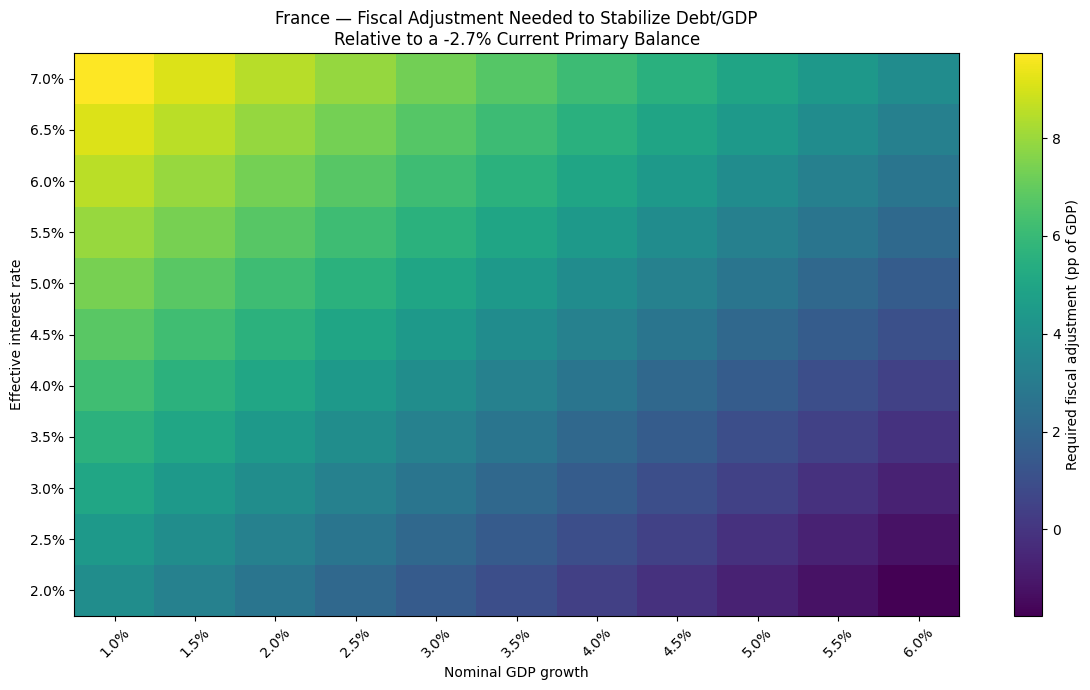

In [38]:

plt.figure(figsize=(12, 7))

img = plt.imshow(
    adjustment_grid * 100,
    aspect="auto",
    origin="lower"
)

plt.colorbar(img, label="Required fiscal adjustment (pp of GDP)")
plt.xticks(
    range(len(growth_grid)),
    [f"{x:.1%}" for x in growth_grid],
    rotation=45
)
plt.yticks(
    range(len(effective_rate_grid)),
    [f"{x:.1%}" for x in effective_rate_grid]
)
plt.xlabel("Nominal GDP growth")
plt.ylabel("Effective interest rate")
plt.title(
    "France — Fiscal Adjustment Needed to Stabilize Debt/GDP\n"
    "Relative to a -2.7% Current Primary Balance"
)

plt.tight_layout()
plt.show()



### How to read the heatmap

Each cell asks:

> Starting from a primary deficit of 2.7% of GDP, how many percentage points of fiscal adjustment would be needed to stabilize debt/GDP if the effective interest rate and nominal growth eventually settled at these levels?

This is the core object we will later combine with an estimated **fiscal reaction function** to distinguish difficult scenarios from historically implausible ones.


## 8. A configurable 30Y OAT → average new funding-cost bridge


A 30-year OAT yield cannot be inserted directly into the debt equation.

France issues across the curve. We therefore define an **illustrative yield-curve scenario** around a chosen 30Y OAT rate and weight the nodes by an assumed issuance mix.

For now the curve offsets and issuance weights are explicit assumptions. They are intentionally easy to replace later with AFT issuance weights and observed/estimated yield curves.

\[
r_t^{new} = \sum_m w_m y_{m,t}
\]


In [39]:

# ============================================================
# ILLUSTRATIVE MAPPING — EDIT THESE ASSUMPTIONS
# ============================================================

# Yield-node offsets relative to the 30Y OAT scenario.
# Example: -0.010 means that maturity is assumed to yield
# 1 percentage point less than the 30Y.
curve_offsets_to_30y = {
    "2Y":  -0.0125,
    "5Y":  -0.0100,
    "10Y": -0.0060,
    "15Y": -0.0035,
    "30Y":  0.0000,
    "50Y":  0.0015
}

# Illustrative issuance weights.
# These are NOT yet calibrated AFT issuance shares.
issuance_weights = {
    "2Y":  0.10,
    "5Y":  0.20,
    "10Y": 0.30,
    "15Y": 0.15,
    "30Y": 0.20,
    "50Y": 0.05
}

assert np.isclose(sum(issuance_weights.values()), 1.0)


In [40]:

def scenario_curve_from_30y(
    oat_30y_yield,
    offsets=curve_offsets_to_30y
):
    return {
        maturity: oat_30y_yield + offset
        for maturity, offset in offsets.items()
    }


def weighted_new_funding_cost(
    curve,
    weights=issuance_weights
):
    return sum(
        weights[maturity] * curve[maturity]
        for maturity in weights
    )


oat_30y_scenarios = np.arange(0.05, 0.0751, 0.0025)

mapping_rows = []

for oat30 in oat_30y_scenarios:
    curve = scenario_curve_from_30y(oat30)
    avg_cost = weighted_new_funding_cost(curve)

    mapping_rows.append({
        "OAT_30Y": oat30,
        "illustrative_avg_new_funding_cost": avg_cost,
        **curve
    })

oat_mapping = pd.DataFrame(mapping_rows)

oat_mapping.style.format("{:.2%}")


,OAT_30Y,illustrative_avg_new_funding_cost,2Y,5Y,10Y,15Y,30Y,50Y
0,5.00%,4.45%,3.75%,4.00%,4.40%,4.65%,5.00%,5.15%
1,5.25%,4.70%,4.00%,4.25%,4.65%,4.90%,5.25%,5.40%
2,5.50%,4.95%,4.25%,4.50%,4.90%,5.15%,5.50%,5.65%
3,5.75%,5.20%,4.50%,4.75%,5.15%,5.40%,5.75%,5.90%
4,6.00%,5.45%,4.75%,5.00%,5.40%,5.65%,6.00%,6.15%
5,6.25%,5.70%,5.00%,5.25%,5.65%,5.90%,6.25%,6.40%
6,6.50%,5.95%,5.25%,5.50%,5.90%,6.15%,6.50%,6.65%
7,6.75%,6.20%,5.50%,5.75%,6.15%,6.40%,6.75%,6.90%
8,7.00%,6.45%,5.75%,6.00%,6.40%,6.65%,7.00%,7.15%
9,7.25%,6.70%,6.00%,6.25%,6.65%,6.90%,7.25%,7.40%



**Do not interpret the mapping above as an econometric estimate.**

Its purpose is to prevent the more serious error of assuming `30Y OAT = average French refinancing rate`.

A later step can replace these assumptions with:
1. actual AFT issuance weights by maturity,
2. a fitted French zero-coupon curve,
3. scenario shifts to level/slope/curvature.


## 9. Run debt paths by 30Y OAT scenario

In [41]:

oat_scenario_results = {}
oat_scenario_summary = []

for _, row in oat_mapping.iterrows():
    oat30 = row["OAT_30Y"]
    avg_new_cost = row["illustrative_avg_new_funding_cost"]

    df = project_debt_path(
        initial_debt_ratio=initial_debt_gdp,
        initial_effective_rate=initial_effective_rate,
        new_borrowing_rate=avg_new_cost,
        nominal_growth=nominal_growth,
        primary_balance=primary_balance,
        repricing_speed=repricing_speed,
        years=projection_years
    )

    oat_scenario_results[oat30] = df

    y10 = df.loc[df["year"] == 10].iloc[0]

    oat_scenario_summary.append({
        "OAT_30Y": oat30,
        "avg_new_funding_cost": avg_new_cost,
        "effective_rate_y10": y10["effective_rate"],
        "debt_gdp_y10": y10["debt_gdp"],
        "interest_gdp_y10": y10["interest_expense_gdp"],
        "required_pb_y10": y10["required_primary_balance"],
        "fiscal_gap_y10": y10["fiscal_gap"]
    })

oat_scenario_summary = pd.DataFrame(oat_scenario_summary)

oat_scenario_summary.style.format({
    "OAT_30Y": "{:.2%}",
    "avg_new_funding_cost": "{:.2%}",
    "effective_rate_y10": "{:.2%}",
    "debt_gdp_y10": "{:.1%}",
    "interest_gdp_y10": "{:.2%}",
    "required_pb_y10": "{:.2%}",
    "fiscal_gap_y10": "{:.2%}"
})


,OAT_30Y,avg_new_funding_cost,effective_rate_y10,debt_gdp_y10,interest_gdp_y10,required_pb_y10,fiscal_gap_y10
0,5.00%,4.45%,3.79%,160.6%,5.77%,2.56%,5.26%
1,5.25%,4.70%,3.97%,162.2%,6.10%,2.86%,5.56%
2,5.50%,4.95%,4.15%,164.0%,6.43%,3.16%,5.86%
3,5.75%,5.20%,4.33%,165.7%,6.77%,3.47%,6.17%
4,6.00%,5.45%,4.51%,167.4%,7.11%,3.79%,6.49%
5,6.25%,5.70%,4.69%,169.2%,7.46%,4.11%,6.81%
6,6.50%,5.95%,4.87%,170.9%,7.81%,4.43%,7.13%
7,6.75%,6.20%,5.05%,172.7%,8.17%,4.76%,7.46%
8,7.00%,6.45%,5.23%,174.5%,8.54%,5.10%,7.80%
9,7.25%,6.70%,5.41%,176.4%,8.91%,5.44%,8.14%


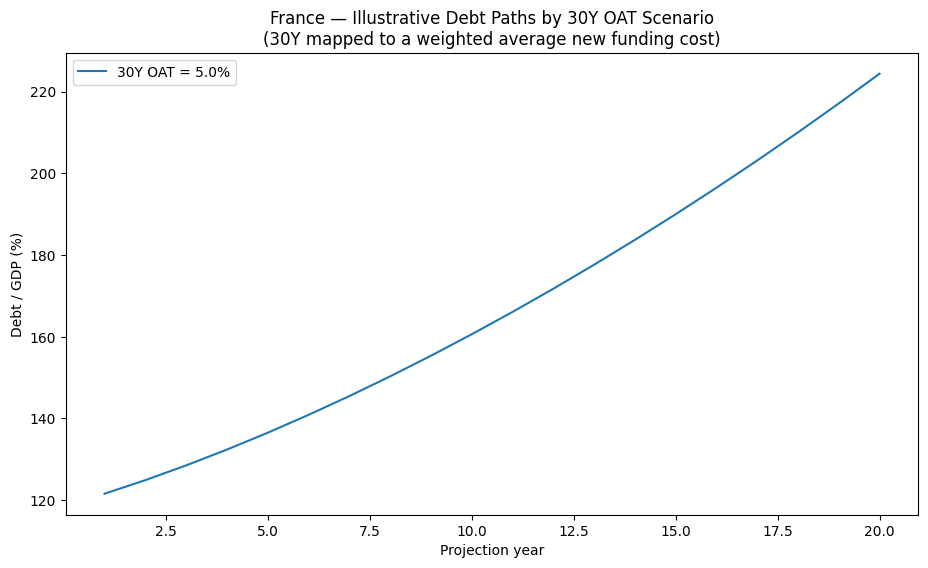

In [42]:

plt.figure(figsize=(11, 6))

for oat30, df in oat_scenario_results.items():
    if oat30 in [0.05, 0.055, 0.06, 0.065, 0.07, 0.075]:
        plt.plot(
            df["year"],
            df["debt_gdp"] * 100,
            label=f"30Y OAT = {oat30:.1%}"
        )

plt.xlabel("Projection year")
plt.ylabel("Debt / GDP (%)")
plt.title(
    "France — Illustrative Debt Paths by 30Y OAT Scenario\n"
    "(30Y mapped to a weighted average new funding cost)"
)
plt.legend()
plt.show()


## 10. Fiscal-adjustment curve by 30Y OAT scenario

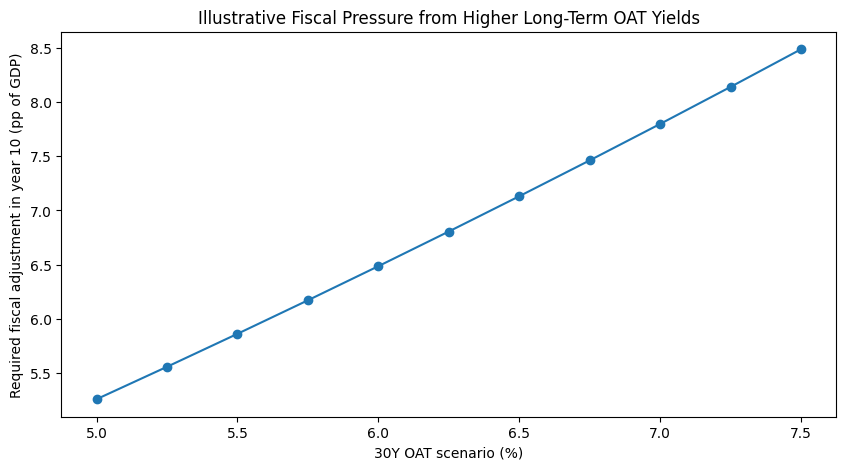

In [43]:

plt.figure(figsize=(10, 5))

plt.plot(
    oat_scenario_summary["OAT_30Y"] * 100,
    oat_scenario_summary["fiscal_gap_y10"] * 100,
    marker="o"
)

plt.xlabel("30Y OAT scenario (%)")
plt.ylabel("Required fiscal adjustment in year 10 (pp of GDP)")
plt.title(
    "Illustrative Fiscal Pressure from Higher Long-Term OAT Yields"
)
plt.show()



This is the first object that resembles an **endogenous stress threshold**.

It still does **not** tell us that a particular 30Y yield is impossible.

Instead it tells us:

> Under this yield-curve mapping and refinancing speed, how large a primary-balance adjustment would France eventually need?

In `04_fiscal_reaction.ipynb`, we will estimate how large a fiscal adjustment France has historically been able to deliver. The intersection of those two objects is much closer to a defensible fiscal-limit concept.


## 11. Near-term AFT maturity wall — contextual check

In [44]:

# Nominal OAT principal currently outstanding by maturity year.
# Source: Agence France Trésor detailed OAT outstanding table.
# This is a contextual subset and excludes inflation-linked OATs and BTFs.

nominal_oat_maturities_bn = {
    2027: 165.642,
    2028: 228.417232603,
    2029: 249.525880462,
    2030: 193.027,
    2031: 194.081,
    2032: 179.078322600,
    2033: 113.845,
    2034: 117.383,
    2035: 151.499,
    2036: 112.585
}

maturity_df = pd.DataFrame({
    "year": list(nominal_oat_maturities_bn.keys()),
    "nominal_OAT_maturities_EUR_bn": list(nominal_oat_maturities_bn.values())
})

maturity_df


,year,nominal_OAT_maturities_EUR_bn
0,2027,165.6420
1,2028,228.4172
2,2029,249.5259
3,2030,193.0270
4,2031,194.0810
5,2032,179.0783
6,2033,113.8450
7,2034,117.3830
8,2035,151.4990
9,2036,112.5850


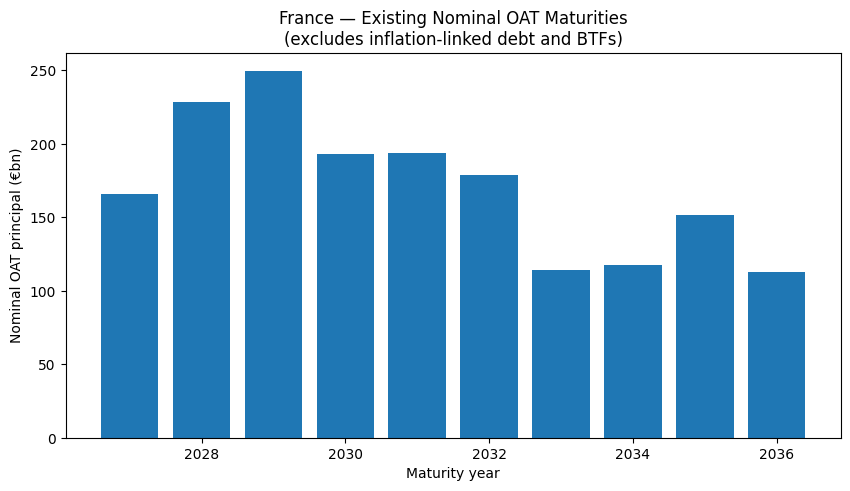

In [45]:

plt.figure(figsize=(10, 5))
plt.bar(
    maturity_df["year"],
    maturity_df["nominal_OAT_maturities_EUR_bn"]
)
plt.xlabel("Maturity year")
plt.ylabel("Nominal OAT principal (€bn)")
plt.title(
    "France — Existing Nominal OAT Maturities\n"
    "(excludes inflation-linked debt and BTFs)"
)
plt.show()



The maturity profile reinforces the central point: the shock from higher yields is **distributed through time**.

Version 0.2 can replace the simple \(1/	ext{average maturity}\) repricing rule with a vintage-level engine that tracks:
- each bond's principal,
- coupon,
- maturity,
- inflation linkage,
- new issuance replacing maturities,
- new issuance financing primary deficits.

That will materially improve the interest-expense path.


## 12. Key outputs

In [46]:

key_outputs = pd.DataFrame({
    "metric": [
        "Initial debt/GDP",
        "Current primary balance/GDP",
        "Nominal GDP growth assumption",
        "Initial effective interest rate",
        "Average debt maturity",
        "Approx. annual repricing speed",
        "Baseline new borrowing rate"
    ],
    "value": [
        f"{initial_debt_gdp:.1%}",
        f"{primary_balance:.1%}",
        f"{nominal_growth:.2%}",
        f"{initial_effective_rate:.2%}",
        f"{average_maturity_years:.2f} years",
        f"{repricing_speed:.2%}",
        f"{baseline_new_borrowing_rate:.2%}"
    ]
})

key_outputs


,metric,value
0,Initial debt/GDP,118.5%
1,Current primary balance/GDP,-2.7%
2,Nominal GDP growth assumption,2.11%
3,Initial effective interest rate,2.11%
4,Average debt maturity,8.39 years
5,Approx. annual repricing speed,11.92%
6,Baseline new borrowing rate,3.50%



## 13. Conclusions and limitations

### What this notebook can do

- enforce the sovereign-debt accounting identity;
- distinguish market yields from the effective cost of the debt stock;
- model gradual repricing;
- calculate debt-stabilizing primary balances;
- quantify the fiscal adjustment implied by different growth/rate combinations;
- translate configurable 30Y OAT scenarios into approximate refinancing-pressure scenarios.

### What it cannot yet do

- forecast GDP growth endogenously;
- estimate the OAT-Bund spread;
- model the full AFT debt vintage/coupon structure;
- model fiscal policy as an endogenous reaction;
- assign probabilities to scenarios;
- model crisis/non-crisis regimes;
- estimate a literal market yield ceiling.

### Next notebook

`02_stochastic_dsa.ipynb`

It will replace fixed growth, rates and primary balances with jointly distributed shocks and Monte Carlo paths, allowing questions such as:

\[
P(Debt/GDP > 150\% \mid OAT_{30}=7\%)
\]

and:

\[
P(	ext{required primary adjustment}>5\%\ GDP)
\]

The deterministic notebook should remain the accounting backbone for every later model.
